<a href="https://colab.research.google.com/github/sidneyppratt-svg/yield-curve-monitor/blob/main/yield_curve_monitor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance pandas numpy matplotlib scikit-learn --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [ ]:
# ── Cell 2: Download Treasury yield data ──────────────────────
# ^IRX = 13-week T-Bill (3 month)
# ^FVX = 5-year Treasury yield
# ^TNX = 10-year Treasury yield
# ^TYX = 30-year Treasury yield
# We use ^IRX (2yr proxy) and ^TNX (10yr) for the classic curve

tickers = {
    '3M':  '^IRX',
    '5Y':  '^FVX',
    '10Y': '^TNX',
    '30Y': '^TYX',
}

print("Downloading Treasury yield data 2000-2026...")

yields = pd.DataFrame()
for name, ticker in tickers.items():
    data = yf.download(ticker,
        start='2000-01-01',
        end='2026-09-20',
        auto_adjust=True,
        progress=False)['Close']
    yields[name] = data

yields = yields.dropna()

print(f"✅ Downloaded {len(yields)} trading days of yield data")
print(f"   Date range: {yields.index[0].date()} to {yields.index[-1].date()}")
print(f"\nLatest yields:")
print(f"   3-Month:  {yields['3M'].iloc[-1]:.2f}%")
print(f"   5-Year:   {yields['5Y'].iloc[-1]:.2f}%")
print(f"   10-Year:  {yields['10Y'].iloc[-1]:.2f}%")
print(f"   30-Year:  {yields['30Y'].iloc[-1]:.2f}%")
print(f"\nYield curve shape:")
spread_10_3m = yields['10Y'].iloc[-1] - yields['3M'].iloc[-1]
spread_30_10 = yields['30Y'].iloc[-1] - yields['10Y'].iloc[-1]
print(f"   10Y minus 3M spread: {spread_10_3m:.2f}%")
print(f"   30Y minus 10Y spread: {spread_30_10:.2f}%")
if spread_10_3m < 0:
    print(f"\n⚠️  INVERTED — 3M yield higher than 10Y yield")
else:
    print(f"\n✅  NORMAL — curve is upward sloping")

✅ Downloaded 6712 trading days of yield data
   Date range: 2000-01-03 to 2026-09-18

Latest yields:
   3-Month:  3.98%
   5-Year:   4.86%
   10-Year:  5.00%
   30-Year:  5.33%

Yield curve shape:
   10Y minus 3M spread: 1.02%
   30Y minus 10Y spread: 0.33%

✅  NORMAL — curve is upward sloping


In [ ]:
# ── Cell 3: Spreads and regime classification ──────────────────

# Classic yield curve spreads
yields['10Y_3M']  = yields['10Y'] - yields['3M']   # Main inversion signal
yields['10Y_5Y']  = yields['10Y'] - yields['5Y']   # Mid curve
yields['30Y_10Y'] = yields['30Y'] - yields['10Y']  # Long end

# Regime classification based on 10Y minus 3M spread
def classify_regime(spread):
    if spread < -0.50:
        return 'DEEPLY INVERTED'
    elif spread < 0:
        return 'INVERTED'
    elif spread < 0.50:
        return 'FLAT'
    elif spread < 1.50:
        return 'NORMAL'
    else:
        return 'STEEP'

yields['regime'] = yields['10Y_3M'].apply(classify_regime)

# Rolling 21-day average for smoothing
yields['spread_smooth'] = yields['10Y_3M'].rolling(21).mean()

# Summary stats
print("=" * 60)
print("   YIELD CURVE ANALYSIS — 2000 to 2026")
print("=" * 60)

current_spread  = yields['10Y_3M'].iloc[-1]
current_regime  = yields['regime'].iloc[-1]
current_date    = yields.index[-1].strftime('%B %d, %Y')
pct_rank        = (yields['10Y_3M'] < current_spread).mean() * 100
avg_spread      = yields['10Y_3M'].mean()
min_spread      = yields['10Y_3M'].min()
max_spread      = yields['10Y_3M'].max()
min_date        = yields['10Y_3M'].idxmin().strftime('%B %Y')
max_date        = yields['10Y_3M'].idxmax().strftime('%B %Y')

print(f"\n  Current Reading — {current_date}")
print(f"  10Y minus 3M Spread: {current_spread:.2f}%")
print(f"  Regime:              {current_regime}")
print(f"  Percentile Rank:     {pct_rank:.0f}th percentile since 2000")
print(f"\n  Historical Context:")
print(f"  Average spread:      {avg_spread:.2f}%")
print(f"  Deepest inversion:   {min_spread:.2f}% ({min_date})")
print(f"  Steepest curve:      {max_spread:.2f}% ({max_date})")

print(f"\n  Regime Distribution (% of trading days since 2000):")
regime_counts = yields['regime'].value_counts(normalize=True) * 100
for regime, pct in regime_counts.items():
    bar = '█' * int(pct / 2)
    print(f"  {regime:<20} {pct:5.1f}%  {bar}")

print(f"\n  Key Inversion Periods:")
inverted = yields[yields['10Y_3M'] < 0]
if len(inverted) > 0:
    print(f"  Total inverted days: {len(inverted)} "
          f"({len(inverted)/len(yields)*100:.1f}% of all days)")

print(f"\n{'=' * 60}")
print("✅ Regime classification complete!")

   YIELD CURVE ANALYSIS — 2000 to 2026

  Current Reading — September 18, 2026
  10Y minus 3M Spread: 1.02%
  Regime:              NORMAL
  Percentile Rank:     39th percentile since 2000

  Historical Context:
  Average spread:      1.42%
  Deepest inversion:   -1.70% (May 2023)
  Steepest curve:      3.87% (May 2004)

  Regime Distribution (% of trading days since 2000):
  STEEP                 50.3%  █████████████████████████
  NORMAL                22.7%  ███████████
  FLAT                  13.2%  ██████
  DEEPLY INVERTED        7.0%  ███
  INVERTED               6.7%  ███

  Key Inversion Periods:
  Total inverted days: 924 (13.8% of all days)

✅ Regime classification complete!


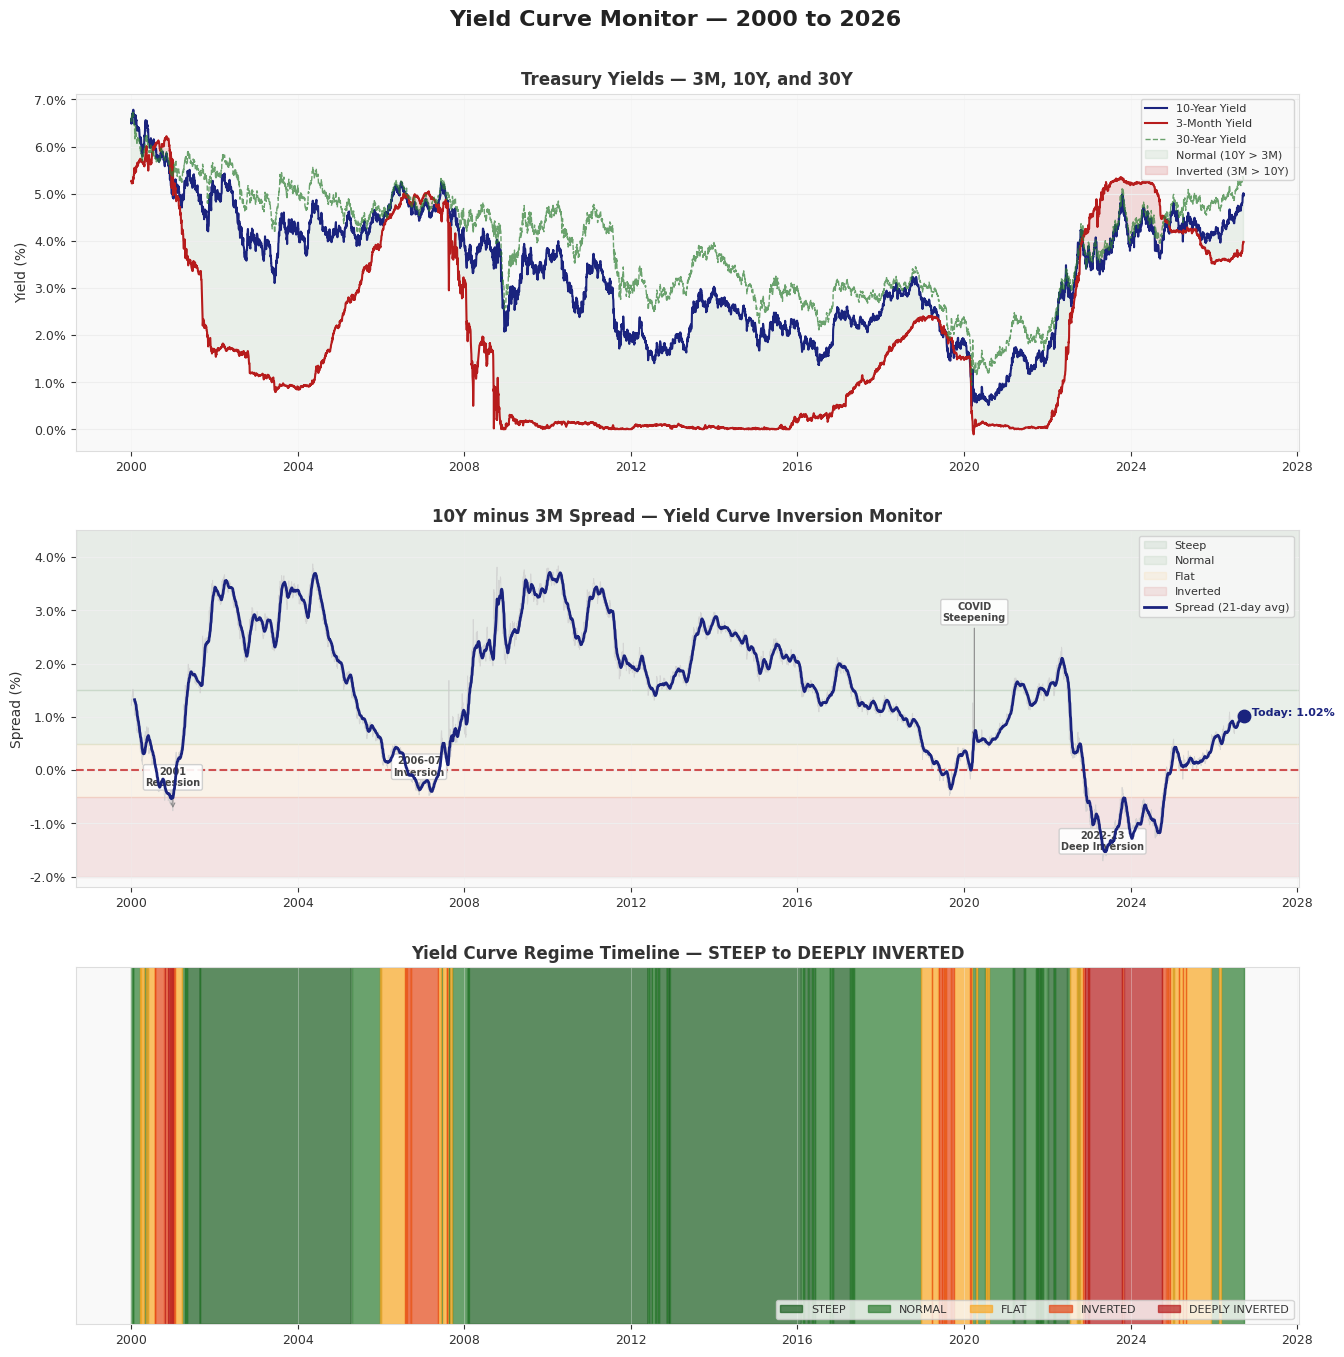

✅ Charts saved as yield_curve_monitor.png!


In [ ]:
# ── Cell 4: Yield curve visualizations ────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.patch.set_facecolor('#FFFFFF')
fig.suptitle('Yield Curve Monitor — 2000 to 2026',
    fontsize=16, fontweight='bold', color='#222222', y=0.98)

for ax in axes:
    ax.set_facecolor('#F9F9F9')
    ax.tick_params(colors='#333333', labelsize=9)
    ax.xaxis.label.set_color('#333333')
    ax.yaxis.label.set_color('#333333')
    for spine in ax.spines.values():
        spine.set_edgecolor('#DDDDDD')
    ax.grid(axis='y', color='#EEEEEE', linewidth=0.8)
    ax.grid(axis='x', color='#EEEEEE', linewidth=0.5, alpha=0.5)

# ── Chart 1: 10Y and 3M yields over time ──────────────────────
axes[0].plot(yields.index, yields['10Y'],
    color='#1A237E', linewidth=1.5, label='10-Year Yield')
axes[0].plot(yields.index, yields['3M'],
    color='#B71C1C', linewidth=1.5, label='3-Month Yield')
axes[0].plot(yields.index, yields['30Y'],
    color='#2E7D32', linewidth=1.0,
    linestyle='--', alpha=0.7, label='30-Year Yield')
axes[0].fill_between(yields.index,
    yields['3M'], yields['10Y'],
    where=yields['10Y'] >= yields['3M'],
    color='#2E7D32', alpha=0.08, label='Normal (10Y > 3M)')
axes[0].fill_between(yields.index,
    yields['3M'], yields['10Y'],
    where=yields['10Y'] < yields['3M'],
    color='#C62828', alpha=0.15, label='Inverted (3M > 10Y)')
axes[0].set_title('Treasury Yields — 3M, 10Y, and 30Y',
    color='#333333', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Yield (%)', color='#333333')
axes[0].legend(facecolor='#F9F9F9',
    labelcolor='#333333', fontsize=8, loc='upper right')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

# ── Chart 2: 10Y minus 3M spread with regime shading ──────────
spread = yields['10Y_3M']
smooth = yields['spread_smooth']

# Regime color bands
axes[1].axhspan(1.50, 5.00, color='#1B5E20', alpha=0.08, label='Steep')
axes[1].axhspan(0.50, 1.50, color='#2E7D32', alpha=0.08, label='Normal')
axes[1].axhspan(-0.50, 0.50, color='#F9A825', alpha=0.08, label='Flat')
axes[1].axhspan(-2.00, -0.50, color='#C62828', alpha=0.10, label='Inverted')
axes[1].axhline(y=0, color='#C62828',
    linewidth=1.5, linestyle='--', alpha=0.8, zorder=3)

# Raw spread and smoothed
axes[1].plot(spread.index, spread.values,
    color='#CCCCCC', linewidth=0.6, alpha=0.7)
axes[1].plot(smooth.index, smooth.values,
    color='#1A237E', linewidth=2.0,
    label='Spread (21-day avg)', zorder=4)

# Current value dot
axes[1].scatter(yields.index[-1], spread.iloc[-1],
    color='#1A237E', s=80, zorder=5)
axes[1].annotate(f'  Today: {spread.iloc[-1]:.2f}%',
    xy=(yields.index[-1], spread.iloc[-1]),
    fontsize=8, color='#1A237E', fontweight='bold')

# Key event annotations
key_events = [
    ('2001-01-01', -0.3, '2001\nRecession'),
    ('2006-12-01', -0.1, '2006-07\nInversion'),
    ('2020-04-01',  2.8, 'COVID\nSteepening'),
    ('2023-05-01', -1.5, '2022-23\nDeep Inversion'),
]
for date_str, y_pos, label_text in key_events:
    try:
        event_date = pd.Timestamp(date_str)
        idx = yields.index.get_indexer([event_date], method='nearest')[0]
        closest = yields.index[idx]
        axes[1].annotate(label_text,
            xy=(closest, yields['10Y_3M'].loc[closest]),
            xytext=(closest, y_pos),
            fontsize=7, color='#444444', ha='center',
            fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#888888',
                lw=0.8),
            bbox=dict(boxstyle='round,pad=0.2',
                facecolor='white',
                edgecolor='#CCCCCC', alpha=0.9))
    except Exception:
        pass

axes[1].set_title(
    '10Y minus 3M Spread — Yield Curve Inversion Monitor',
    color='#333333', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Spread (%)', color='#333333')
axes[1].set_ylim(-2.2, 4.5)
axes[1].legend(facecolor='#F9F9F9',
    labelcolor='#333333', fontsize=8, loc='upper right')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

# ── Chart 3: Regime timeline ───────────────────────────────────
regime_colors = {
    'STEEP':           '#1B5E20',
    'NORMAL':          '#2E7D32',
    'FLAT':            '#F9A825',
    'INVERTED':        '#E64A19',
    'DEEPLY INVERTED': '#B71C1C',
}
regime_num = yields['regime'].map({
    'STEEP':           5,
    'NORMAL':          4,
    'FLAT':            3,
    'INVERTED':        2,
    'DEEPLY INVERTED': 1,
})
for regime, color in regime_colors.items():
    mask = yields['regime'] == regime
    axes[2].fill_between(yields.index, 0, 1,
        where=mask, color=color,
        alpha=0.7, label=regime)

axes[2].set_title(
    'Yield Curve Regime Timeline — STEEP to DEEPLY INVERTED',
    color='#333333', fontsize=12, fontweight='bold')
axes[2].set_yticks([])
axes[2].set_ylim(0, 1)
axes[2].legend(facecolor='#F9F9F9',
    labelcolor='#333333', fontsize=8,
    loc='lower right', ncol=5)

plt.tight_layout(pad=2.5)
plt.savefig('yield_curve_monitor.png',
    dpi=150, bbox_inches='tight',
    facecolor='white')
plt.show()
print("✅ Charts saved as yield_curve_monitor.png!")

In [ ]:
# ── Cell 5: Backtest a yield curve strategy ────────────────────
print("Downloading TLT data for backtest...")
tlt = yf.download('TLT',
    start='2003-01-01',
    end='2026-09-20',
    auto_adjust=True,
    progress=False)['Close']

# Flatten in case yfinance returns multi-index
if isinstance(tlt.columns if hasattr(tlt, 'columns') else [], pd.MultiIndex):
    tlt = tlt.iloc[:, 0]
tlt = tlt.squeeze()

# Align with yield data
common_idx  = yields.index.intersection(tlt.index)
tlt         = tlt.loc[common_idx]
yields_bt   = yields.loc[common_idx].copy()

# Daily returns
tlt_returns = tlt.pct_change().dropna()
yields_bt   = yields_bt.loc[tlt_returns.index]

# Signal: 1 = hold TLT, 0 = cash
signal = yields_bt['regime'].shift(1).isin(
    ['NORMAL', 'STEEP']).astype(int)
signal = signal.loc[tlt_returns.index]

# Strategy returns
strat_returns = (signal * tlt_returns).dropna()
bh_returns    = tlt_returns.loc[strat_returns.index]

# Performance metrics
def get_metrics(r):
    r   = r.dropna()
    cum = (1 + r).cumprod()
    total   = float(cum.iloc[-1]) - 1
    ann_ret = float((1 + total) ** (252 / len(r)) - 1)
    ann_vol = float(r.std() * np.sqrt(252))
    sharpe  = float(ann_ret / ann_vol) if ann_vol > 0 else 0.0
    max_dd  = float((cum / cum.cummax() - 1).min())
    return cum, total, ann_ret, ann_vol, sharpe, max_dd

cum_s, tot_s, ret_s, vol_s, sh_s, dd_s = get_metrics(strat_returns)
cum_b, tot_b, ret_b, vol_b, sh_b, dd_b = get_metrics(bh_returns)

print("=" * 60)
print("   YIELD CURVE STRATEGY BACKTEST — TLT 2003 to 2026")
print("=" * 60)
print(f"\n  {'Metric':<22} {'Strategy':>12} {'Buy & Hold':>12}")
print(f"  {'─'*46}")
print(f"  {'Total Return':<22} {tot_s:>11.1%} {tot_b:>11.1%}")
print(f"  {'Ann. Return':<22} {ret_s:>11.1%} {ret_b:>11.1%}")
print(f"  {'Volatility':<22} {vol_s:>11.1%} {vol_b:>11.1%}")
print(f"  {'Sharpe Ratio':<22} {sh_s:>11.2f} {sh_b:>11.2f}")
print(f"  {'Max Drawdown':<22} {dd_s:>11.1%} {dd_b:>11.1%}")

days_invested = int(signal.sum())
pct_invested  = float(signal.mean() * 100)
print(f"\n  Signal Stats:")
print(f"  Days holding TLT:    {days_invested} ({pct_invested:.1f}% of time)")
print(f"  Days in cash:        {len(signal)-days_invested} "
      f"({100-pct_invested:.1f}% of time)")

print(f"\n{'=' * 60}")
print("✅ Backtest complete!")

   YIELD CURVE STRATEGY BACKTEST — TLT 2003 to 2026

  Metric                     Strategy   Buy & Hold
  ──────────────────────────────────────────────
  Total Return                 91.5%      111.2%
  Ann. Return                   2.8%        3.2%
  Volatility                   12.4%       14.3%
  Sharpe Ratio                  0.23        0.22
  Max Drawdown                -33.0%      -48.4%

  Signal Stats:
  Days holding TLT:    4376 (73.4% of time)
  Days in cash:        1583 (26.6% of time)

✅ Backtest complete!


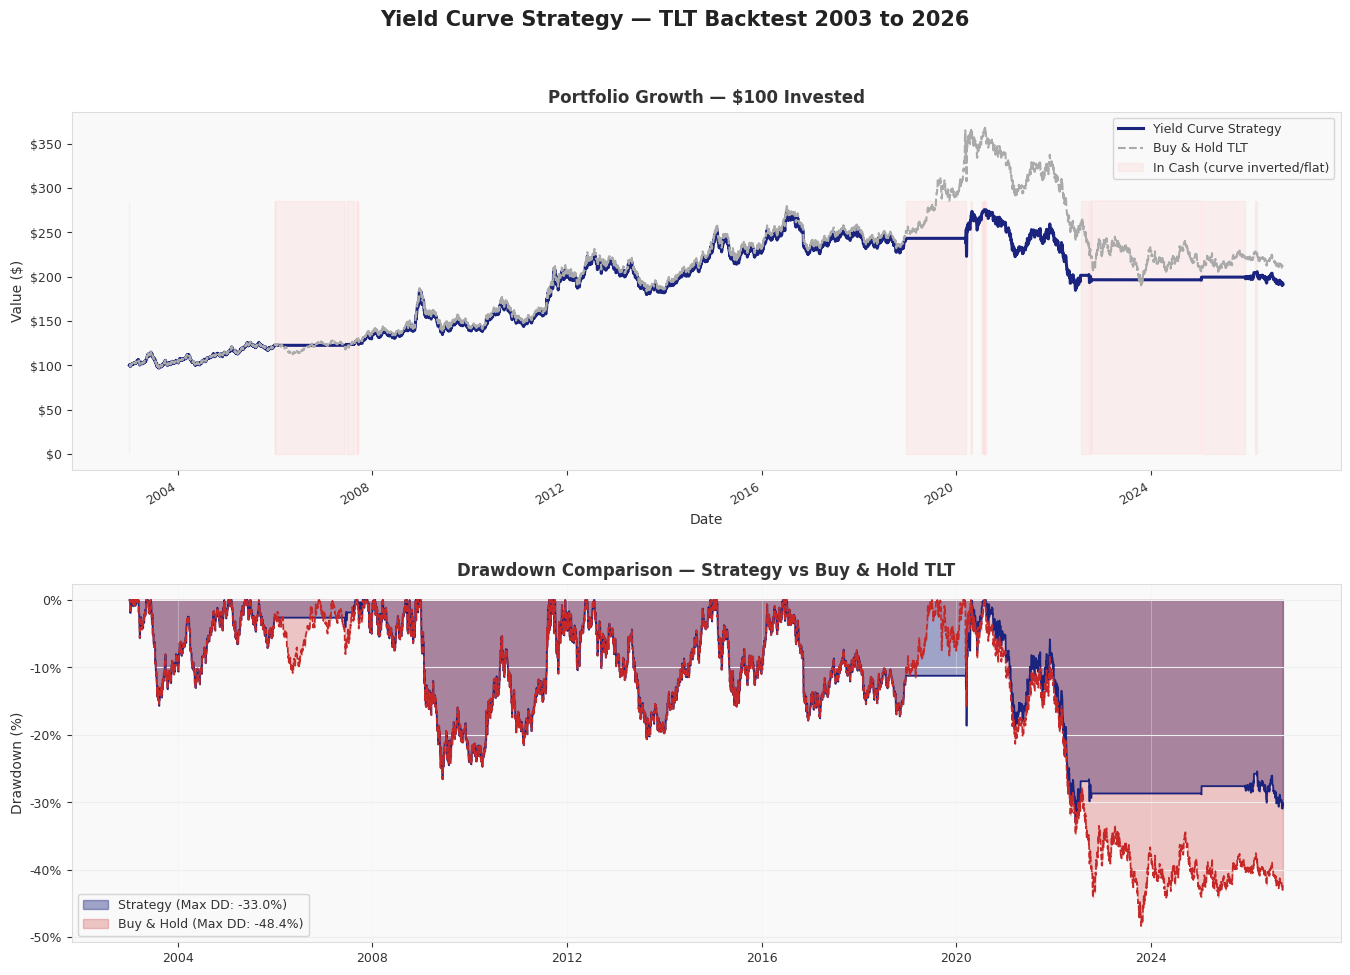

✅ Backtest chart saved as yield_curve_backtest.png!


In [ ]:
# ── Cell 6: Backtest performance chart ────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.patch.set_facecolor('#FFFFFF')
fig.suptitle('Yield Curve Strategy — TLT Backtest 2003 to 2026',
    fontsize=15, fontweight='bold', color='#222222', y=0.99)

for ax in axes:
    ax.set_facecolor('#F9F9F9')
    ax.tick_params(colors='#333333', labelsize=9)
    ax.xaxis.label.set_color('#333333')
    ax.yaxis.label.set_color('#333333')
    for spine in ax.spines.values():
        spine.set_edgecolor('#DDDDDD')
    ax.grid(axis='y', color='#EEEEEE', linewidth=0.8)
    ax.grid(axis='x', color='#EEEEEE', linewidth=0.5, alpha=0.5)

# ── Chart 1: Portfolio growth ──────────────────────────────────
(cum_s * 100).plot(ax=axes[0], color='#1A237E',
    linewidth=2.2, label='Yield Curve Strategy')
(cum_b * 100).plot(ax=axes[0], color='#AAAAAA',
    linewidth=1.5, linestyle='--', label='Buy & Hold TLT')

# Shade cash periods
cash_mask = signal == 0
axes[0].fill_between(strat_returns.index, 0,
    float(cum_s.max() * 100) + 10,
    where=cash_mask.reindex(strat_returns.index).fillna(False),
    color='#FFCCCC', alpha=0.25, label='In Cash (curve inverted/flat)')

axes[0].set_title('Portfolio Growth — $100 Invested',
    color='#333333', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Value ($)', color='#333333')
axes[0].legend(facecolor='#F9F9F9',
    labelcolor='#333333', fontsize=9)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:.0f}'))

# ── Chart 2: Drawdown comparison ──────────────────────────────
dd_strat = (cum_s / cum_s.cummax() - 1) * 100
dd_bh    = (cum_b / cum_b.cummax() - 1) * 100

axes[1].fill_between(dd_strat.index, 0, dd_strat.values,
    color='#1A237E', alpha=0.4, label=f'Strategy (Max DD: {dd_s:.1%})')
axes[1].fill_between(dd_bh.index, 0, dd_bh.values,
    color='#C62828', alpha=0.25,
    label=f'Buy & Hold (Max DD: {dd_b:.1%})')
axes[1].plot(dd_strat.index, dd_strat.values,
    color='#1A237E', linewidth=1.2)
axes[1].plot(dd_bh.index, dd_bh.values,
    color='#C62828', linewidth=1.2, linestyle='--')

axes[1].set_title('Drawdown Comparison — Strategy vs Buy & Hold TLT',
    color='#333333', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Drawdown (%)', color='#333333')
axes[1].legend(facecolor='#F9F9F9',
    labelcolor='#333333', fontsize=9)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout(pad=2.5)
plt.savefig('yield_curve_backtest.png',
    dpi=150, bbox_inches='tight',
    facecolor='white')
plt.show()
print("✅ Backtest chart saved as yield_curve_backtest.png!")

In [ ]:
# ── Cell 7: Full yield curve report with recommendations ───────

def generate_yield_curve_report(yields, tot_s, tot_b, dd_s, dd_b):

    current_spread  = float(yields['10Y_3M'].iloc[-1])
    current_regime  = yields['regime'].iloc[-1]
    current_10y     = float(yields['10Y'].iloc[-1])
    current_3m      = float(yields['3M'].iloc[-1])
    current_5y      = float(yields['5Y'].iloc[-1])
    current_30y     = float(yields['30Y'].iloc[-1])
    current_date    = yields.index[-1].strftime('%B %d, %Y')
    pct_rank        = float((yields['10Y_3M'] < current_spread).mean() * 100)
    avg_spread      = float(yields['10Y_3M'].mean())
    spread_vs_avg   = current_spread - avg_spread
    trend_30d       = float(yields['10Y_3M'].iloc[-1] -
                            yields['10Y_3M'].iloc[-22])
    trend_90d       = float(yields['10Y_3M'].iloc[-1] -
                            yields['10Y_3M'].iloc[-63])

    print("=" * 65)
    print("   YIELD CURVE MONITOR — LIVE REPORT")
    print("=" * 65)
    print(f"\n  Date: {current_date}")

    print(f"\n{'─' * 65}")
    print("  CURRENT YIELDS")
    print(f"{'─' * 65}")
    print(f"  3-Month:   {current_3m:.2f}%  ← short term borrowing cost")
    print(f"  5-Year:    {current_5y:.2f}%  ← medium term")
    print(f"  10-Year:   {current_10y:.2f}%  ← benchmark rate")
    print(f"  30-Year:   {current_30y:.2f}%  ← long term cost of money")

    print(f"\n{'─' * 65}")
    print("  YIELD CURVE SHAPE")
    print(f"{'─' * 65}")
    print(f"  10Y minus 3M:   {current_spread:+.2f}%")
    print(f"  10Y minus 5Y:   {float(yields['10Y_5Y'].iloc[-1]):+.2f}%")
    print(f"  30Y minus 10Y:  {float(yields['30Y_10Y'].iloc[-1]):+.2f}%")
    print(f"\n  Regime:          {current_regime}")
    print(f"  Percentile:      {pct_rank:.0f}th percentile since 2000")
    print(f"  vs Average:      {spread_vs_avg:+.2f}% vs historical avg "
          f"of {avg_spread:.2f}%")

    # Trend
    if trend_30d > 0.10:
        trend_label = f"STEEPENING FAST (+{trend_30d:.2f}% last 30 days)"
    elif trend_30d > 0:
        trend_label = f"STEEPENING SLOWLY (+{trend_30d:.2f}% last 30 days)"
    elif trend_30d < -0.10:
        trend_label = f"FLATTENING FAST ({trend_30d:.2f}% last 30 days)"
    else:
        trend_label = f"FLATTENING SLOWLY ({trend_30d:.2f}% last 30 days)"
    print(f"  30-Day Trend:    {trend_label}")

    # 90 day trend
    if trend_90d > 0:
        trend_90_label = f"STEEPENING (+{trend_90d:.2f}% last 90 days)"
    else:
        trend_90_label = f"FLATTENING ({trend_90d:.2f}% last 90 days)"
    print(f"  90-Day Trend:    {trend_90_label}")

    print(f"\n{'─' * 65}")
    print("  INTERPRETATION")
    print(f"{'─' * 65}")

    interpretations = {
        'DEEPLY INVERTED': {
            'summary': 'The yield curve is deeply inverted — one of the '
                       'most reliable recession warning signals in all of '
                       'finance. Short term rates are significantly higher '
                       'than long term rates.',
            'what_it_means': [
                'Think of it this way: normally a bank pays you more interest '
                'to lock your money away for 10 years than for 3 months. '
                'Right now it is backwards — 3 month deposits pay more than '
                '10 year bonds. That is called an inversion.',
                'This happens when the Federal Reserve has raised short term '
                'rates aggressively to fight inflation. The market is now '
                'betting that the Fed will have to cut rates in the future '
                'because the economy will slow down.',
                'Historically a deeply inverted curve has preceded every '
                'major US recession since 1970. The recession typically '
                'arrives 12 to 18 months after the inversion begins.',
            ],
            'what_to_watch': [
                'Watch for the Fed to start cutting rates — that is when '
                'the curve will begin to uninvert.',
                'Watch unemployment claims — rising jobless claims often '
                'confirm the recession signal.',
                'Watch credit spreads — if HYG falls sharply alongside '
                'the inversion that is a double warning signal.',
                'Watch for the curve to steepen rapidly — that often '
                'signals the recession has actually begun.',
            ],
            'strategy_signal': 'MOVE TO CASH — the model signals avoiding '
                               'long duration bonds like TLT during deep '
                               'inversions. The 2022-23 inversion saw TLT '
                               'fall over 48% peak to trough.',
        },
        'INVERTED': {
            'summary': 'The yield curve is inverted — short term rates are '
                       'higher than long term rates. This is a classic '
                       'recession warning signal.',
            'what_it_means': [
                'Short term borrowing costs are higher than long term costs. '
                'This is the opposite of normal and signals that markets '
                'expect the economy to slow and the Fed to cut rates.',
                'Banks borrow short and lend long — an inverted curve '
                'squeezes bank profit margins which reduces lending and '
                'slows economic growth.',
                'The inversion suggests bond investors believe growth '
                'will slow and inflation will fall — which is why they '
                'are willing to accept lower yields on 10 year bonds.',
            ],
            'what_to_watch': [
                'Watch how long the inversion lasts — longer inversions '
                'produce deeper recessions historically.',
                'Watch the Fed — rate cuts are likely coming.',
                'Watch credit markets for signs of stress.',
                'A rapid steepening from inversion often means the '
                'recession has already begun.',
            ],
            'strategy_signal': 'MOVE TO CASH — model signals caution on '
                               'long duration bonds. Wait for the curve to '
                               'return to flat or normal before re-entering.',
        },
        'FLAT': {
            'summary': 'The yield curve is flat — short and long term '
                       'rates are nearly equal. This is a transition zone '
                       'and the direction from here matters enormously.',
            'what_it_means': [
                'A flat curve means the market is uncertain about the '
                'future. Short term and long term borrowing costs are '
                'almost the same which is unusual.',
                'This often happens when the economy is transitioning — '
                'either heading toward an inversion and potential recession '
                'or recovering from one and heading back to normal.',
                'Think of the flat curve as a crossroads. The direction '
                'it moves from here tells you a lot about where the '
                'economy is headed.',
            ],
            'what_to_watch': [
                'Direction is everything — is the curve flattening '
                'toward inversion or steepening toward normal?',
                'Watch the Fed for guidance on future rate moves.',
                'Watch economic data — strong growth data steepens '
                'the curve, weak data flattens it further.',
                'A flat curve flattening further is a warning sign.',
            ],
            'strategy_signal': 'MOVE TO CASH — model signals caution '
                               'during flat curve periods. The risk of '
                               'tipping into inversion is elevated.',
        },
        'NORMAL': {
            'summary': 'The yield curve is normal — long term rates are '
                       'higher than short term rates. This is the healthy '
                       'baseline for a growing economy.',
            'what_it_means': [
                'This is how the curve is supposed to look. You get paid '
                'more to lend money for 10 years than for 3 months because '
                'there is more uncertainty over longer time periods.',
                'A normal curve means banks can borrow cheap short term '
                'and lend at higher long term rates — that is profitable '
                'for banks which means more lending and economic growth.',
                'The Fed is likely in a neutral or slightly accommodative '
                'stance. Growth is positive and inflation is manageable.',
            ],
            'what_to_watch': [
                'Watch whether the curve is steepening or flattening '
                f'— currently {trend_label.lower()}.',
                'A steepening normal curve is a bullish economic signal.',
                'Watch for the curve to flatten toward zero — that '
                'would be an early warning sign.',
                'Long duration bonds like TLT perform well in this '
                'environment if rates are stable or falling.',
            ],
            'strategy_signal': 'HOLD TLT — model signals it is safe to '
                               'hold long duration bonds. Monitor for any '
                               'flattening trend which would be a warning.',
        },
        'STEEP': {
            'summary': 'The yield curve is steep — long term rates are '
                       'well above short term rates. This often signals '
                       'strong growth expectations or high inflation.',
            'what_it_means': [
                'A steep curve usually appears in one of two situations: '
                'after a recession when the Fed has cut short rates to '
                'near zero and the economy is recovering, or when '
                'inflation expectations are rising sharply.',
                'The market is demanding significantly more compensation '
                'for lending money long term — either because it expects '
                'inflation to erode purchasing power or because it '
                'expects strong growth and higher future rates.',
                'Historically a steep curve has been one of the best '
                'environments for economic growth — banks are very '
                'profitable and lending is abundant.',
            ],
            'what_to_watch': [
                'Watch inflation data — a steep curve driven by '
                'inflation fears can turn negative if inflation '
                'gets out of control.',
                'Watch the Fed — they may hike short rates which '
                'will gradually flatten the curve.',
                'A steepening curve after a recession is one of the '
                'best signals that growth is recovering.',
                f'Currently {trend_label.lower()} — watch for direction.',
            ],
            'strategy_signal': 'HOLD TLT — model signals holding long '
                               'duration bonds. Steep curves can be '
                               'volatile for bonds if inflation rises '
                               'so monitor closely.',
        },
    }

    info = interpretations.get(current_regime, {})
    print(f"\n  Summary:")
    print(f"  {info.get('summary', '')}")

    print(f"\n  What This Means in Plain English:")
    for point in info.get('what_it_means', []):
        print(f"\n  • {point}")

    print(f"\n  What to Watch Right Now:")
    for point in info.get('what_to_watch', []):
        print(f"  ➜ {point}")

    print(f"\n  Strategy Signal:")
    print(f"  {info.get('strategy_signal', '')}")

    print(f"\n{'─' * 65}")
    print("  HISTORICAL CONTEXT")
    print(f"{'─' * 65}")
    print(f"  Average 10Y-3M spread since 2000: {avg_spread:.2f}%")
    print(f"  Current vs average:               {spread_vs_avg:+.2f}%")
    print(f"  Deepest inversion: "
          f"{float(yields['10Y_3M'].min()):.2f}% "
          f"({yields['10Y_3M'].idxmin().strftime('%B %Y')})")
    print(f"  Steepest curve:    "
          f"{float(yields['10Y_3M'].max()):.2f}% "
          f"({yields['10Y_3M'].idxmax().strftime('%B %Y')})")

    # Regime distribution
    print(f"\n  Regime Distribution (% of time in selected period):")
    regime_counts = yields['regime'].value_counts(normalize=True) * 100
    for regime, pct in regime_counts.items():
        bar = '█' * int(pct / 3)
        print(f"  {regime:<20} {pct:5.1f}%  {bar}")

    print(f"\n{'─' * 65}")
    print("  BACKTEST RESULTS")
    print(f"{'─' * 65}")
    print(f"  Strategy Total Return:    {tot_s:.1%}")
    print(f"  Buy & Hold Total Return:  {tot_b:.1%}")
    print(f"  Strategy Max Drawdown:    {dd_s:.1%}")
    print(f"  Buy & Hold Max Drawdown:  {dd_b:.1%}")
    print(f"  Drawdown improvement:     "
          f"{abs(dd_b) - abs(dd_s):.1%} less drawdown")
    print(f"  Key insight: The yield curve strategy reduced the "
          f"worst loss from {dd_b:.1%} to {dd_s:.1%} by moving "
          f"to cash during inversion and flat curve periods.")

    print(f"\n{'=' * 65}")
    print("✅ Yield Curve Monitor report complete!")
    print(f"{'=' * 65}")


# ── Run the report ─────────────────────────────────────────────
generate_yield_curve_report(yields, tot_s, tot_b, dd_s, dd_b)

   YIELD CURVE MONITOR — LIVE REPORT

  Date: September 18, 2026

─────────────────────────────────────────────────────────────────
  CURRENT YIELDS
─────────────────────────────────────────────────────────────────
  3-Month:   3.98%  ← short term borrowing cost
  5-Year:    4.86%  ← medium term
  10-Year:   5.00%  ← benchmark rate
  30-Year:   5.33%  ← long term cost of money

─────────────────────────────────────────────────────────────────
  YIELD CURVE SHAPE
─────────────────────────────────────────────────────────────────
  10Y minus 3M:   +1.02%
  10Y minus 5Y:   +0.14%
  30Y minus 10Y:  +0.33%

  Regime:          NORMAL
  Percentile:      39th percentile since 2000
  vs Average:      -0.40% vs historical avg of 1.42%
  30-Day Trend:    STEEPENING SLOWLY (+0.07% last 30 days)
  90-Day Trend:    STEEPENING (+0.19% last 90 days)

─────────────────────────────────────────────────────────────────
  INTERPRETATION
─────────────────────────────────────────────────────────────────

  Su